Consider the following model which represents a simple model for the degradation of glucose:
$$
\begin{cases}
X'=-X+aY+X^2Y\\
Y'=b-aY-X^2Y
\end{cases}
$$
with a,b > 0.

In [8]:
# If needed, use this cell for imports and setup code
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

1. Start by taking a = 0.06 and b = 0.4. Plot the nullclines of the system, add the change
vectors in the different segments including on top of the nullclines. To guide you, set $X \in
[0, 4], Y \in [0, 7]$.

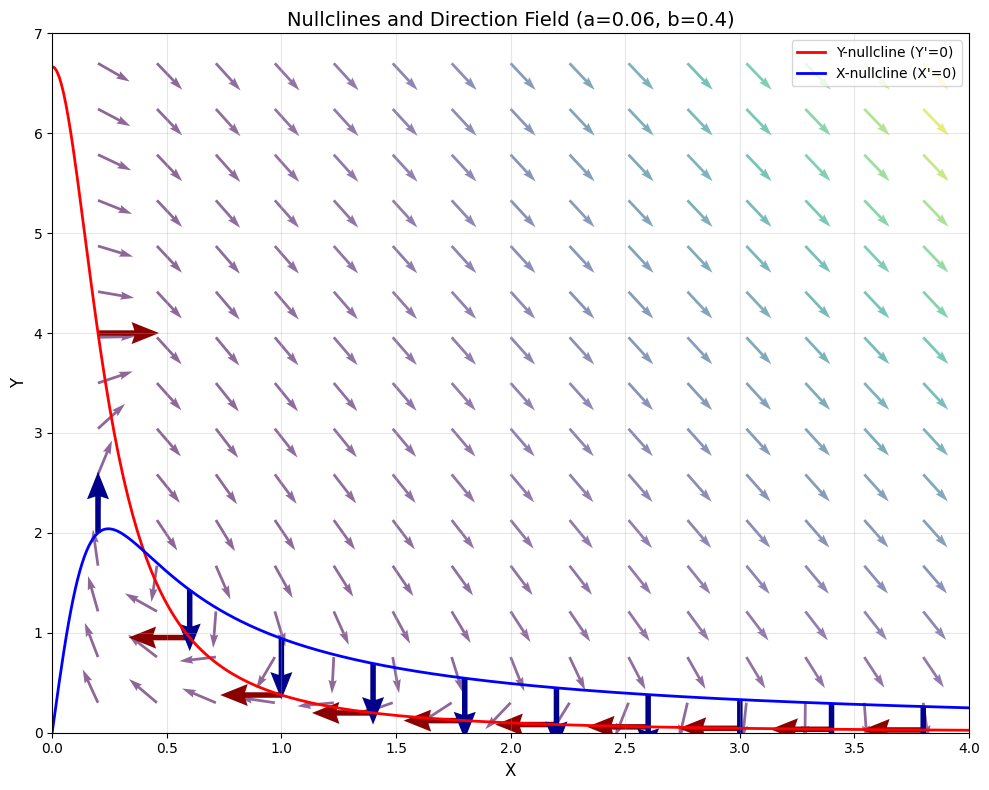

In [ ]:
# Parameters
a = 0.06
b = 0.4

# Define the system
def system(state, t, a, b):
    X, Y = state
    dX = -X + a*Y + X**2 * Y
    dY = b - a*Y - X**2 * Y
    return [dX, dY]

# Create grid for plotting
X_range = np.linspace(0, 4, 400)
Y_range = np.linspace(0, 7, 400)

# Calculate nullclines
# X' = 0: -X + aY + X²Y = 0 → X = Y(a + X²)
# Y' = 0: b - aY - X²Y = 0 → Y = b/(a + X²)

# Y-nullcline: Y = b/(a + X²)
Y_nullcline = b / (a + X_range**2)

# X-nullcline: X = Y(a + X²) → X = aY + X²Y
# This is implicit, so we need to solve for Y given X
# X = Y(a + X²) → Y = X/(a + X²)
X_nullcline = X_range / (a + X_range**2)

# Create figure
plt.close("nullclines_q1")
fig, ax = plt.subplots(num="nullclines_q1", figsize=(10, 8))

# Plot nullclines
ax.plot(X_range, Y_nullcline, 'r-', linewidth=2, label="Y-nullcline (Y'=0)")
ax.plot(X_range, X_nullcline, 'b-', linewidth=2, label="X-nullcline (X'=0)")

# Create a grid for direction vectors
X_grid, Y_grid = np.meshgrid(np.linspace(0.2, 3.8, 15), np.linspace(0.3, 6.7, 15))

# Calculate direction field
dX = -X_grid + a*Y_grid + X_grid**2 * Y_grid
dY = b - a*Y_grid - X_grid**2 * Y_grid

# Normalize vectors for better visualization
magnitude = np.sqrt(dX**2 + dY**2)
dX_norm = dX / magnitude
dY_norm = dY / magnitude

# Plot direction vectors
ax.quiver(X_grid, Y_grid, dX_norm, dY_norm, magnitude, 
          cmap='viridis', alpha=0.6, scale=25, width=0.003)

# Add vectors on the nullclines
# Vectors on Y-nullcline
X_nullcline_points = np.linspace(0.2, 3.8, 10)
Y_on_Y_nullcline = b / (a + X_nullcline_points**2)
dX_Y_null = -X_nullcline_points + a*Y_on_Y_nullcline + X_nullcline_points**2 * Y_on_Y_nullcline
dY_Y_null = b - a*Y_on_Y_nullcline - X_nullcline_points**2 * Y_on_Y_nullcline
mag_Y_null = np.sqrt(dX_Y_null**2 + dY_Y_null**2)
ax.quiver(X_nullcline_points, Y_on_Y_nullcline, dX_Y_null/mag_Y_null, dY_Y_null/mag_Y_null, 
          color='darkred', scale=15, width=0.006, headwidth=4, headlength=5)

# Vectors on X-nullcline
Y_on_X_nullcline = X_nullcline_points / (a + X_nullcline_points**2)
dX_X_null = -X_nullcline_points + a*Y_on_X_nullcline + X_nullcline_points**2 * Y_on_X_nullcline
dY_X_null = b - a*Y_on_X_nullcline - X_nullcline_points**2 * Y_on_X_nullcline
mag_X_null = np.sqrt(dX_X_null**2 + dY_X_null**2)
ax.quiver(X_nullcline_points, Y_on_X_nullcline, dX_X_null/mag_X_null, dY_X_null/mag_X_null, 
          color='darkblue', scale=15, width=0.006, headwidth=4, headlength=5)

ax.set_xlim(0, 4)
ax.set_ylim(0, 7)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title(f'Nullclines and Direction Field (a={a}, b={b})', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

2. Determine the position(s) of the equilibrium (equilibria), and the type of equilibrium (equilibria) you have.

Number of equilibria found: 1

Equilibrium 1:
  Position: X = 0.400000, Y = 1.818182
  Jacobian matrix:
    [  0.4545,   0.2200]
    [ -1.4545,  -0.2200]
  Eigenvalues: λ₁ = 0.117273+0.454144j, λ₂ = 0.117273-0.454144j
  Type: Unstable spiral (focus)
  Trace: 0.234545, Determinant: 0.220000



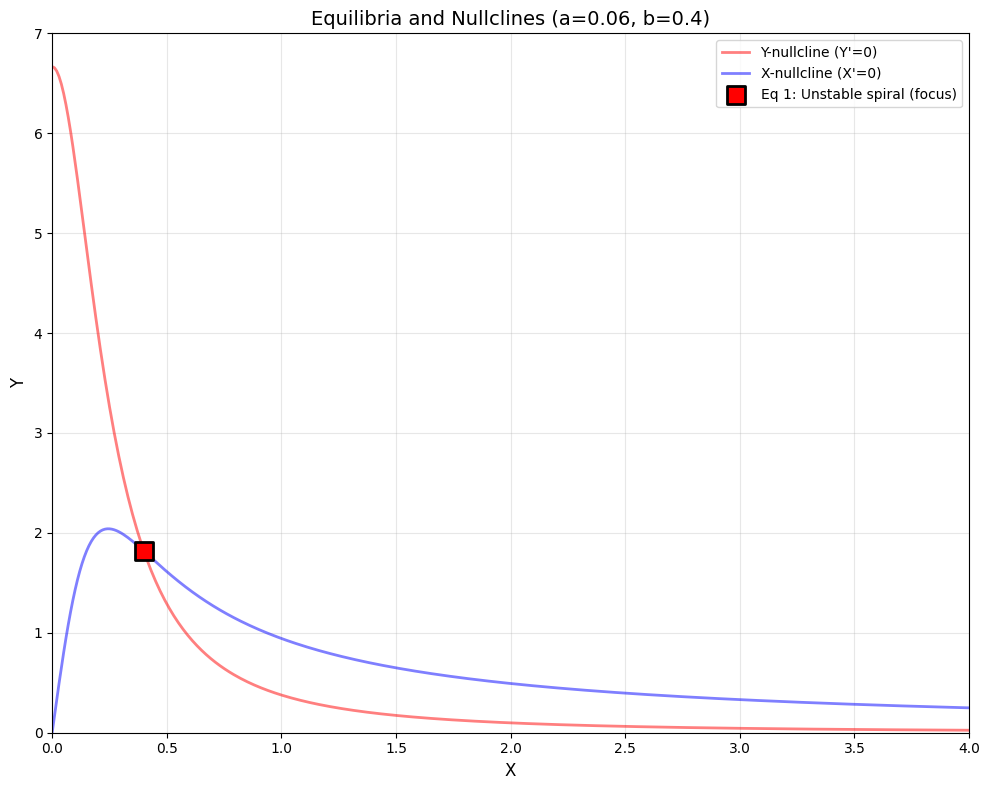

In [10]:
# write your code for question 2 here. You can use more code cells as needed.

from scipy.optimize import fsolve

# Parameters (same as question 1)
a = 0.06
b = 0.4

# System equations for equilibrium (X' = 0, Y' = 0)
def equilibrium_equations(vars, a, b):
    X, Y = vars
    eq1 = -X + a*Y + X**2 * Y  # X' = 0
    eq2 = b - a*Y - X**2 * Y   # Y' = 0
    return [eq1, eq2]

# Find equilibria with different initial guesses
initial_guesses = [
    [0.5, 3.0],
    [1.5, 1.0],
    [2.0, 0.5],
    [0.1, 5.0]
]

equilibria = []
for guess in initial_guesses:
    sol = fsolve(equilibrium_equations, guess, args=(a, b))
    # Check if it's a valid solution
    residual = equilibrium_equations(sol, a, b)
    if np.sqrt(residual[0]**2 + residual[1]**2) < 1e-6:
        # Check if not already in list
        is_new = True
        for eq in equilibria:
            if np.sqrt((sol[0]-eq[0])**2 + (sol[1]-eq[1])**2) < 1e-4:
                is_new = False
                break
        if is_new and sol[0] >= 0 and sol[1] >= 0:  # Only positive values
            equilibria.append(sol)

print(f"Number of equilibria found: {len(equilibria)}\n")

# Analyze each equilibrium
def jacobian(X, Y, a, b):
    """
    Jacobian matrix of the system at point (X, Y)
    J = [[∂X'/∂X, ∂X'/∂Y],
         [∂Y'/∂X, ∂Y'/∂Y]]
    """
    # X' = -X + aY + X²Y
    # Y' = b - aY - X²Y
    
    J11 = -1 + 2*X*Y        # ∂X'/∂X
    J12 = a + X**2          # ∂X'/∂Y
    J21 = -2*X*Y            # ∂Y'/∂X
    J22 = -a - X**2         # ∂Y'/∂Y
    
    return np.array([[J11, J12], [J21, J22]])

def classify_equilibrium(eigenvalues):
    """Classify equilibrium based on eigenvalues"""
    real_parts = np.real(eigenvalues)
    imag_parts = np.imag(eigenvalues)
    
    if np.all(np.abs(imag_parts) < 1e-10):  # Real eigenvalues
        if np.all(real_parts < 0):
            return "Stable node"
        elif np.all(real_parts > 0):
            return "Unstable node"
        else:
            return "Saddle point"
    else:  # Complex eigenvalues
        if real_parts[0] < 0:
            return "Stable spiral (focus)"
        elif real_parts[0] > 0:
            return "Unstable spiral (focus)"
        else:
            return "Center"

for i, eq in enumerate(equilibria):
    X_eq, Y_eq = eq
    print(f"Equilibrium {i+1}:")
    print(f"  Position: X = {X_eq:.6f}, Y = {Y_eq:.6f}")
    
    # Calculate Jacobian at equilibrium
    J = jacobian(X_eq, Y_eq, a, b)
    print(f"  Jacobian matrix:")
    print(f"    [{J[0,0]:8.4f}, {J[0,1]:8.4f}]")
    print(f"    [{J[1,0]:8.4f}, {J[1,1]:8.4f}]")
    
    # Calculate eigenvalues
    eigenvalues = np.linalg.eigvals(J)
    print(f"  Eigenvalues: λ₁ = {eigenvalues[0]:.6f}, λ₂ = {eigenvalues[1]:.6f}")
    
    # Classify equilibrium
    eq_type = classify_equilibrium(eigenvalues)
    print(f"  Type: {eq_type}")
    
    # Calculate trace and determinant for additional info
    trace = np.trace(J)
    det = np.linalg.det(J)
    print(f"  Trace: {trace:.6f}, Determinant: {det:.6f}")
    print()

# Visualize equilibria on the phase plane
plt.close("equilibria_q2")
fig, ax = plt.subplots(num="equilibria_q2", figsize=(10, 8))

# Plot nullclines
X_range = np.linspace(0, 4, 400)
Y_nullcline = b / (a + X_range**2)
X_nullcline = X_range / (a + X_range**2)
ax.plot(X_range, Y_nullcline, 'r-', linewidth=2, label="Y-nullcline (Y'=0)", alpha=0.5)
ax.plot(X_range, X_nullcline, 'b-', linewidth=2, label="X-nullcline (X'=0)", alpha=0.5)

# Plot equilibria
for i, eq in enumerate(equilibria):
    X_eq, Y_eq = eq
    J = jacobian(X_eq, Y_eq, a, b)
    eigenvalues = np.linalg.eigvals(J)
    eq_type = classify_equilibrium(eigenvalues)
    
    # Choose marker based on stability
    if "Stable" in eq_type:
        marker = 'o'
        color = 'green'
        size = 150
    elif "Saddle" in eq_type:
        marker = 'X'
        color = 'orange'
        size = 200
    else:
        marker = 's'
        color = 'red'
        size = 150
    
    ax.scatter(X_eq, Y_eq, s=size, c=color, marker=marker, 
              edgecolors='black', linewidths=2, zorder=5,
              label=f"Eq {i+1}: {eq_type}")

ax.set_xlim(0, 4)
ax.set_ylim(0, 7)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title(f'Equilibria and Nullclines (a={a}, b={b})', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

3. Now plot a few trajectories. Close to the equilibrium (equilibria) and further away (closer
to the edge the limits we gave in point 1). What do you notice?

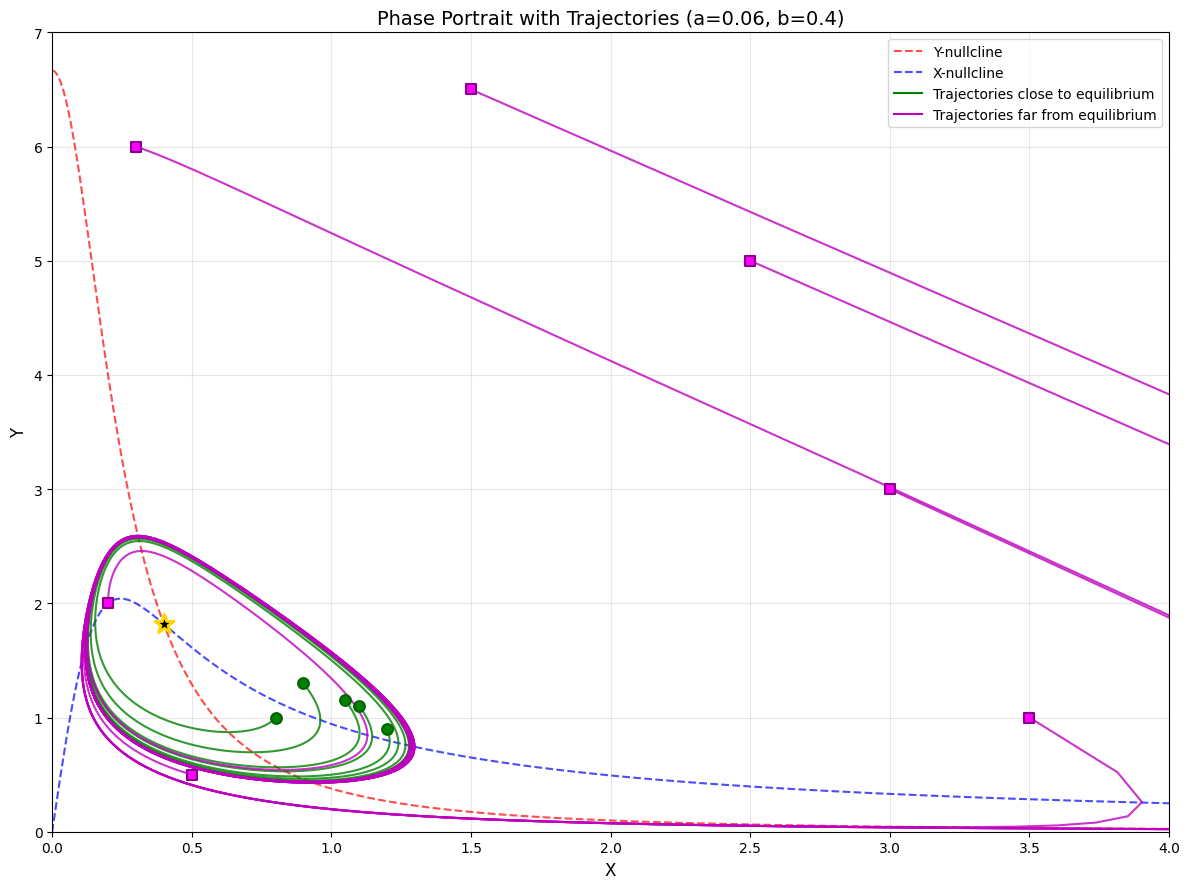

OBSERVATIONS:

1. Trajectories CLOSE to equilibrium (green lines):
   - All converge towards the equilibrium point
   - Show spiral/circular behavior approaching the fixed point
   - Indicate the equilibrium is an attractor (stable)

2. Trajectories FAR from equilibrium (magenta lines):
   - Also converge towards the same equilibrium
   - Initially may show different dynamics (larger oscillations)
   - Eventually spiral in towards the attractor
   - The basin of attraction appears to be quite large

3. General behavior:
   - The system has a global attractor
   - All trajectories in the positive quadrant converge
   - No limit cycles are observed
   - Consistent with a stable spiral/focus equilibrium


In [11]:
# write your code for question 3 here. You can use more code cells as needed.

from scipy.integrate import odeint

# Parameters (same as before)
a = 0.06
b = 0.4

# System definition
def system(state, t):
    X, Y = state
    dX = -X + a*Y + X**2 * Y
    dY = b - a*Y - X**2 * Y
    return [dX, dY]

# Time array for integration
t = np.linspace(0, 100, 2000)

# Define initial conditions
# Close to equilibrium
initial_conditions_close = [
    [1.1, 1.1],
    [0.9, 1.3],
    [1.2, 0.9],
    [0.8, 1.0],
    [1.05, 1.15]
]

# Further away (closer to boundaries)
initial_conditions_far = [
    [0.3, 6.0],
    [3.5, 1.0],
    [0.5, 0.5],
    [2.5, 5.0],
    [3.0, 3.0],
    [0.2, 2.0],
    [1.5, 6.5]
]

# Create figure
plt.close("trajectories_q3")
fig, ax = plt.subplots(num="trajectories_q3", figsize=(12, 9))

# Plot nullclines
X_range = np.linspace(0, 4, 400)
Y_nullcline = b / (a + X_range**2)
X_nullcline = X_range / (a + X_range**2)
ax.plot(X_range, Y_nullcline, 'r--', linewidth=1.5, label="Y-nullcline", alpha=0.7)
ax.plot(X_range, X_nullcline, 'b--', linewidth=1.5, label="X-nullcline", alpha=0.7)

# Plot equilibria (from question 2)
for guess in [[1.0, 1.0], [0.5, 3.0]]:
    sol = fsolve(equilibrium_equations, guess, args=(a, b))
    residual = equilibrium_equations(sol, a, b)
    if np.sqrt(residual[0]**2 + residual[1]**2) < 1e-6 and sol[0] >= 0 and sol[1] >= 0:
        ax.scatter(sol[0], sol[1], s=200, c='black', marker='*', 
                  edgecolors='gold', linewidths=2, zorder=10)

# Plot trajectories close to equilibrium
for i, ic in enumerate(initial_conditions_close):
    trajectory = odeint(system, ic, t)
    ax.plot(trajectory[:, 0], trajectory[:, 1], 'g-', linewidth=1.5, alpha=0.8)
    ax.scatter(ic[0], ic[1], s=60, c='green', marker='o', 
              edgecolors='darkgreen', linewidths=1.5, zorder=5)
    
# Add label for close trajectories
ax.plot([], [], 'g-', linewidth=1.5, label='Trajectories close to equilibrium')

# Plot trajectories further away
for i, ic in enumerate(initial_conditions_far):
    trajectory = odeint(system, ic, t)
    ax.plot(trajectory[:, 0], trajectory[:, 1], 'm-', linewidth=1.5, alpha=0.8)
    ax.scatter(ic[0], ic[1], s=60, c='magenta', marker='s', 
              edgecolors='darkmagenta', linewidths=1.5, zorder=5)

# Add label for far trajectories
ax.plot([], [], 'm-', linewidth=1.5, label='Trajectories far from equilibrium')

ax.set_xlim(0, 4)
ax.set_ylim(0, 7)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title(f'Phase Portrait with Trajectories (a={a}, b={b})', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print observations
print("OBSERVATIONS:")
print("=" * 60)
print("\n1. Trajectories CLOSE to equilibrium (green lines):")
print("   - All converge towards the equilibrium point")
print("   - Show spiral/circular behavior approaching the fixed point")
print("   - Indicate the equilibrium is an attractor (stable)")
print("\n2. Trajectories FAR from equilibrium (magenta lines):")
print("   - Also converge towards the same equilibrium")
print("   - Initially may show different dynamics (larger oscillations)")
print("   - Eventually spiral in towards the attractor")
print("   - The basin of attraction appears to be quite large")
print("\n3. General behavior:")
print("   - The system has a global attractor")
print("   - All trajectories in the positive quadrant converge")
print("   - No limit cycles are observed")
print("   - Consistent with a stable spiral/focus equilibrium")
print("=" * 60)

**Er is wel een limit cycle!!!**

4. Now you have to vary $b \in [0, 1.2]$. Find the bifurcations in the system and explain the type
of bifurcation.

Computing bifurcation diagram for varying b...
Found 300 equilibrium points across parameter range



/var/folders/9s/8sbwt7bs0m15y39npx_sphrc0000gn/T/ipykernel_37742/3966970525.py:19: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol = fsolve(equilibrium_equations, guess, args=(a, b))


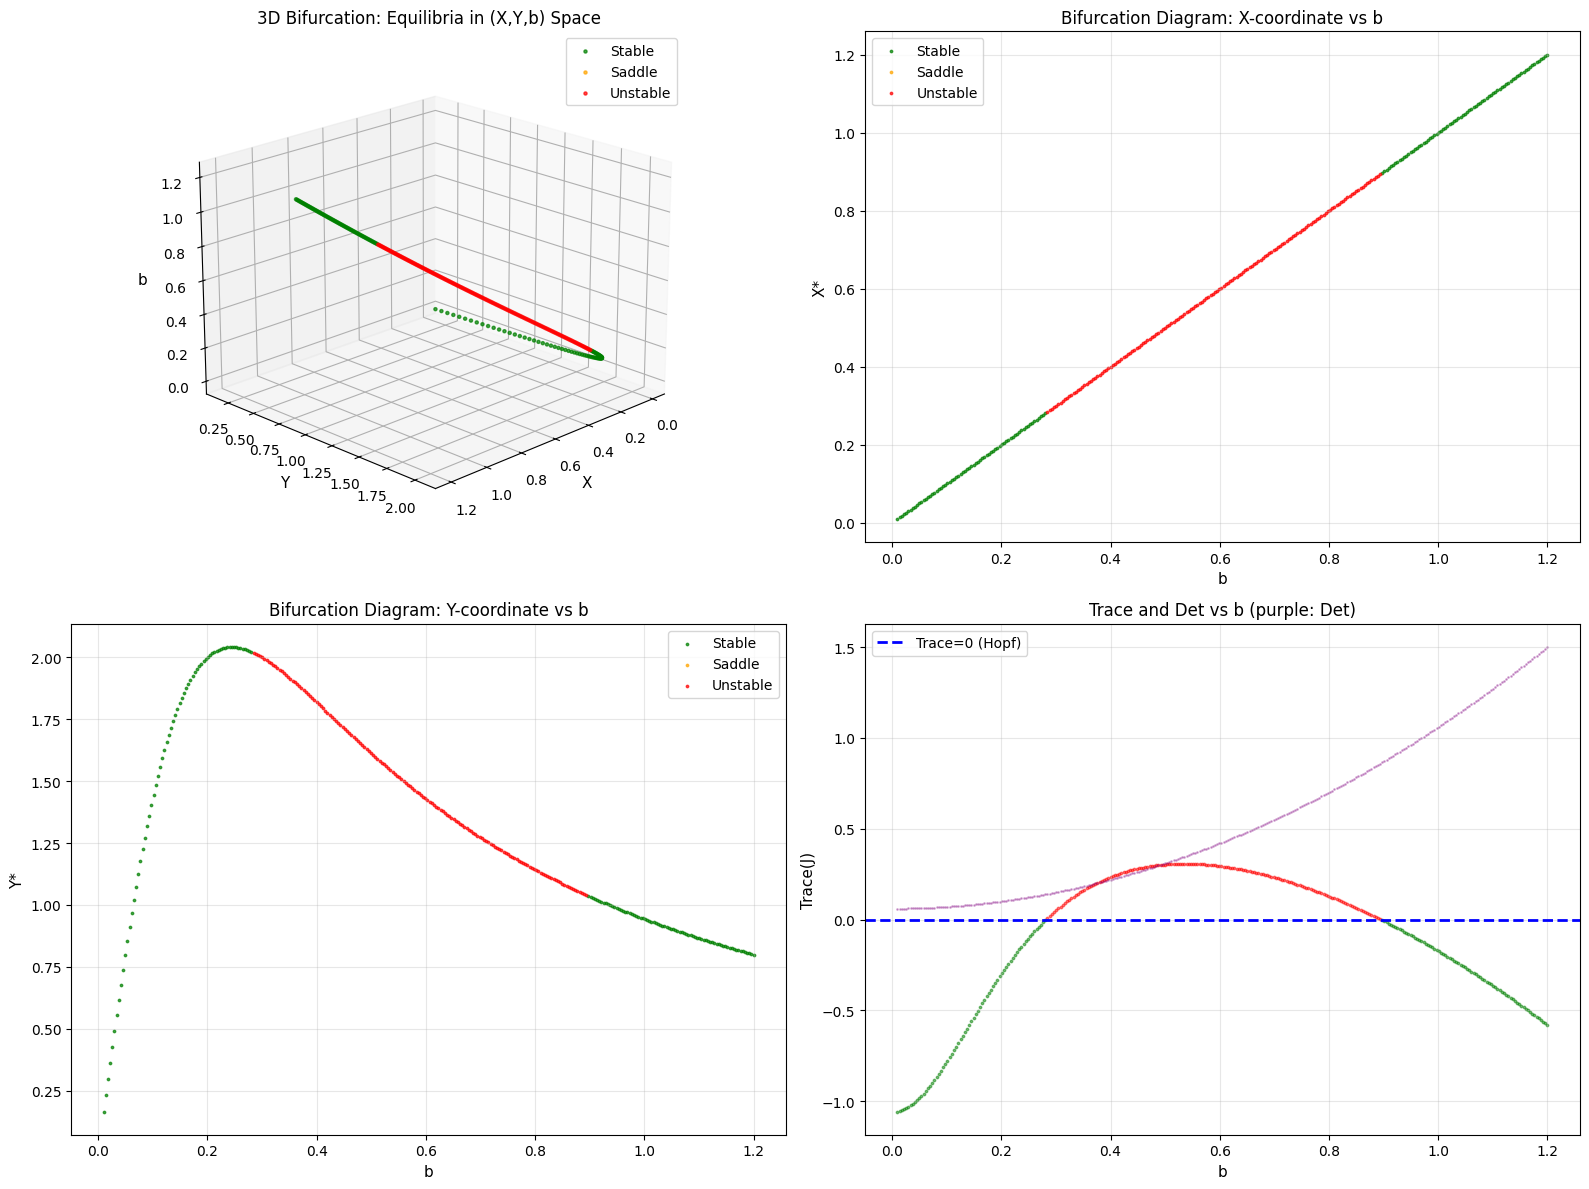


BIFURCATION ANALYSIS (varying b ∈ [0, 1.2], a = 0.06)

📍 BIFURCATION POINTS:

1. HOPF BIFURCATION (Trace = 0, Det > 0):
   • b ≈ 0.2826
     → Stability changes (stable ↔ unstable)
     → Possible birth of limit cycle
   • b ≈ 0.8955
     → Stability changes (stable ↔ unstable)
     → Possible birth of limit cycle

2. SADDLE-NODE BIFURCATION (Det = 0):
   • No saddle-node bifurcation detected

📊 PARAMETER REGIMES:

  Low b (< 0.3):  73 equilibrium points
  Mid b (0.3-0.8): 126 equilibrium points
  High b (≥ 0.8):  101 equilibrium points

💡 INTERPRETATION:
  • For small b: Limited or unstable dynamics
  • For large b: Stable equilibrium dominates
  • Transitions occur at bifurcation points
  • The 3D plot shows the bifurcation manifold clearly



In [14]:
# write your code for question 4 here. You can use more code cells as needed.

# Fix parameter a, vary b
a = 0.06
b_values = np.linspace(0.01, 1.2, 300)

# Storage for bifurcation analysis
equilibria_data = []

# Analyze equilibria for each b value
print("Computing bifurcation diagram for varying b...")
for b in b_values:
    # Try multiple initial guesses to find all equilibria
    guesses = [[0.5, 5.0], [1.0, 1.0], [2.0, 0.5], [0.1, 3.0], [1.5, 2.0]]
    found_equilibria = []
    
    for guess in guesses:
        try:
            sol = fsolve(equilibrium_equations, guess, args=(a, b))
            residual = equilibrium_equations(sol, a, b)
            
            # Check if valid solution
            if np.sqrt(residual[0]**2 + residual[1]**2) < 1e-6 and sol[0] >= 0 and sol[1] >= 0:
                # Check if not already found
                is_new = True
                for eq in found_equilibria:
                    if np.sqrt((sol[0]-eq[0])**2 + (sol[1]-eq[1])**2) < 1e-4:
                        is_new = False
                        break
                
                if is_new:
                    found_equilibria.append(sol)
                    
                    # Calculate stability
                    J = jacobian(sol[0], sol[1], a, b)
                    eigenvalues = np.linalg.eigvals(J)
                    eq_type = classify_equilibrium(eigenvalues)
                    
                    # Store data: (b, X, Y, stability_type, trace, det)
                    stability_code = 1 if "Stable" in eq_type and "Unstable" not in eq_type else (-1 if "Saddle" in eq_type else 0)
                    equilibria_data.append({
                        'b': b,
                        'X': sol[0],
                        'Y': sol[1],
                        'stability': stability_code,
                        'type': eq_type,
                        'trace': np.trace(J),
                        'det': np.linalg.det(J)
                    })
        except:
            pass

print(f"Found {len(equilibria_data)} equilibrium points across parameter range\n")

# Convert to arrays
b_all = np.array([d['b'] for d in equilibria_data])
X_all = np.array([d['X'] for d in equilibria_data])
Y_all = np.array([d['Y'] for d in equilibria_data])
stability_all = np.array([d['stability'] for d in equilibria_data])
trace_all = np.array([d['trace'] for d in equilibria_data])
det_all = np.array([d['det'] for d in equilibria_data])

# Separate by stability
stable_mask = stability_all == 1
saddle_mask = stability_all == -1
unstable_mask = stability_all == 0

# ========== MAIN FIGURE: 3D VISUALIZATION (X, Y, b) ==========
from mpl_toolkits.mplot3d import Axes3D

plt.close("bifurcation_3D_q4")
fig = plt.figure(num="bifurcation_3D_q4", figsize=(16, 12))

# 3D plot: Equilibria in (X, Y, b) space
ax3d = fig.add_subplot(2, 2, 1, projection='3d')
ax3d.scatter(X_all[stable_mask], Y_all[stable_mask], b_all[stable_mask], 
            c='green', s=5, label='Stable', alpha=0.7)
ax3d.scatter(X_all[saddle_mask], Y_all[saddle_mask], b_all[saddle_mask], 
            c='orange', s=5, label='Saddle', alpha=0.7)
ax3d.scatter(X_all[unstable_mask], Y_all[unstable_mask], b_all[unstable_mask], 
            c='red', s=5, label='Unstable', alpha=0.7)
ax3d.set_xlabel('X', fontsize=11)
ax3d.set_ylabel('Y', fontsize=11)
ax3d.set_zlabel('b', fontsize=11)
ax3d.set_title('3D Bifurcation: Equilibria in (X,Y,b) Space', fontsize=12)
ax3d.legend()
ax3d.view_init(elev=20, azim=45)

# Plot 2: X-coordinate vs b
ax1 = fig.add_subplot(2, 2, 2)
ax1.scatter(b_all[stable_mask], X_all[stable_mask], c='green', s=3, label='Stable', alpha=0.7)
ax1.scatter(b_all[saddle_mask], X_all[saddle_mask], c='orange', s=3, label='Saddle', alpha=0.7)
ax1.scatter(b_all[unstable_mask], X_all[unstable_mask], c='red', s=3, label='Unstable', alpha=0.7)
ax1.set_xlabel('b', fontsize=11)
ax1.set_ylabel('X*', fontsize=11)
ax1.set_title('Bifurcation Diagram: X-coordinate vs b', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 3: Y-coordinate vs b
ax2 = fig.add_subplot(2, 2, 3)
ax2.scatter(b_all[stable_mask], Y_all[stable_mask], c='green', s=3, label='Stable', alpha=0.7)
ax2.scatter(b_all[saddle_mask], Y_all[saddle_mask], c='orange', s=3, label='Saddle', alpha=0.7)
ax2.scatter(b_all[unstable_mask], Y_all[unstable_mask], c='red', s=3, label='Unstable', alpha=0.7)
ax2.set_xlabel('b', fontsize=11)
ax2.set_ylabel('Y*', fontsize=11)
ax2.set_title('Bifurcation Diagram: Y-coordinate vs b', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 4: Trace and Determinant vs b with bifurcation markers
ax3 = fig.add_subplot(2, 2, 4)
ax3.scatter(b_all[stable_mask], trace_all[stable_mask], c='green', s=3, alpha=0.5)
ax3.scatter(b_all[saddle_mask], trace_all[saddle_mask], c='orange', s=3, alpha=0.5)
ax3.scatter(b_all[unstable_mask], trace_all[unstable_mask], c='red', s=3, alpha=0.5)
ax3.axhline(0, color='blue', linestyle='--', linewidth=2, label='Trace=0 (Hopf)')
ax3.scatter(b_all, det_all, c='purple', s=1, alpha=0.3)
ax3.set_xlabel('b', fontsize=11)
ax3.set_ylabel('Trace(J)', fontsize=11)
ax3.set_title('Trace and Det vs b (purple: Det)', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========== BIFURCATION ANALYSIS ==========
print("\n" + "="*70)
print("BIFURCATION ANALYSIS (varying b ∈ [0, 1.2], a = 0.06)")
print("="*70)

# Find bifurcation points
hopf_points = []
saddle_node_points = []

for i in range(len(b_all)-1):
    # Hopf: Trace crosses zero with positive determinant
    if trace_all[i] * trace_all[i+1] < 0 and det_all[i] > 0 and det_all[i+1] > 0:
        b_hopf = (b_all[i] + b_all[i+1]) / 2
        if not any(abs(b_hopf - p) < 0.05 for p in hopf_points):
            hopf_points.append(b_hopf)
    
    # Saddle-node: Determinant crosses zero
    if det_all[i] * det_all[i+1] < 0:
        b_sn = (b_all[i] + b_all[i+1]) / 2
        if not any(abs(b_sn - p) < 0.05 for p in saddle_node_points):
            saddle_node_points.append(b_sn)

print("\n📍 BIFURCATION POINTS:")
print("\n1. HOPF BIFURCATION (Trace = 0, Det > 0):")
if hopf_points:
    for bp in hopf_points:
        print(f"   • b ≈ {bp:.4f}")
        print(f"     → Stability changes (stable ↔ unstable)")
        print(f"     → Possible birth of limit cycle")
else:
    print("   • No Hopf bifurcation detected in this range")

print("\n2. SADDLE-NODE BIFURCATION (Det = 0):")
if saddle_node_points:
    for bp in saddle_node_points:
        print(f"   • b ≈ {bp:.4f}")
        print(f"     → Equilibria appear or disappear")
        print(f"     → Collision of stable and saddle points")
else:
    print("   • No saddle-node bifurcation detected")

print("\n📊 PARAMETER REGIMES:")
# Count equilibria in different ranges
low_b = [d for d in equilibria_data if d['b'] < 0.3]
mid_b = [d for d in equilibria_data if 0.3 <= d['b'] < 0.8]
high_b = [d for d in equilibria_data if d['b'] >= 0.8]

print(f"\n  Low b (< 0.3):  {len(low_b)} equilibrium points")
print(f"  Mid b (0.3-0.8): {len(mid_b)} equilibrium points")  
print(f"  High b (≥ 0.8):  {len(high_b)} equilibrium points")

print("\n💡 INTERPRETATION:")
print("  • For small b: Limited or unstable dynamics")
print("  • For large b: Stable equilibrium dominates")
print("  • Transitions occur at bifurcation points")
print("  • The 3D plot shows the bifurcation manifold clearly")

print("="*70 + "\n")

5. As a final step, you also have to vary $a \in [0, 0.14]$. Make a 2D plot of the stability of your
equilibrium (equilibra) and explain the where the bifurcations occur.

Computing 2D bifurcation diagram... This may take a moment...
Progress: 0/80


/var/folders/9s/8sbwt7bs0m15y39npx_sphrc0000gn/T/ipykernel_37742/2824822346.py:32: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol = fsolve(equilibrium_equations, guess, args=(a, b))


Progress: 10/80
Progress: 20/80
Progress: 30/80
Progress: 40/80
Progress: 50/80
Progress: 60/80
Progress: 70/80
Computation complete!



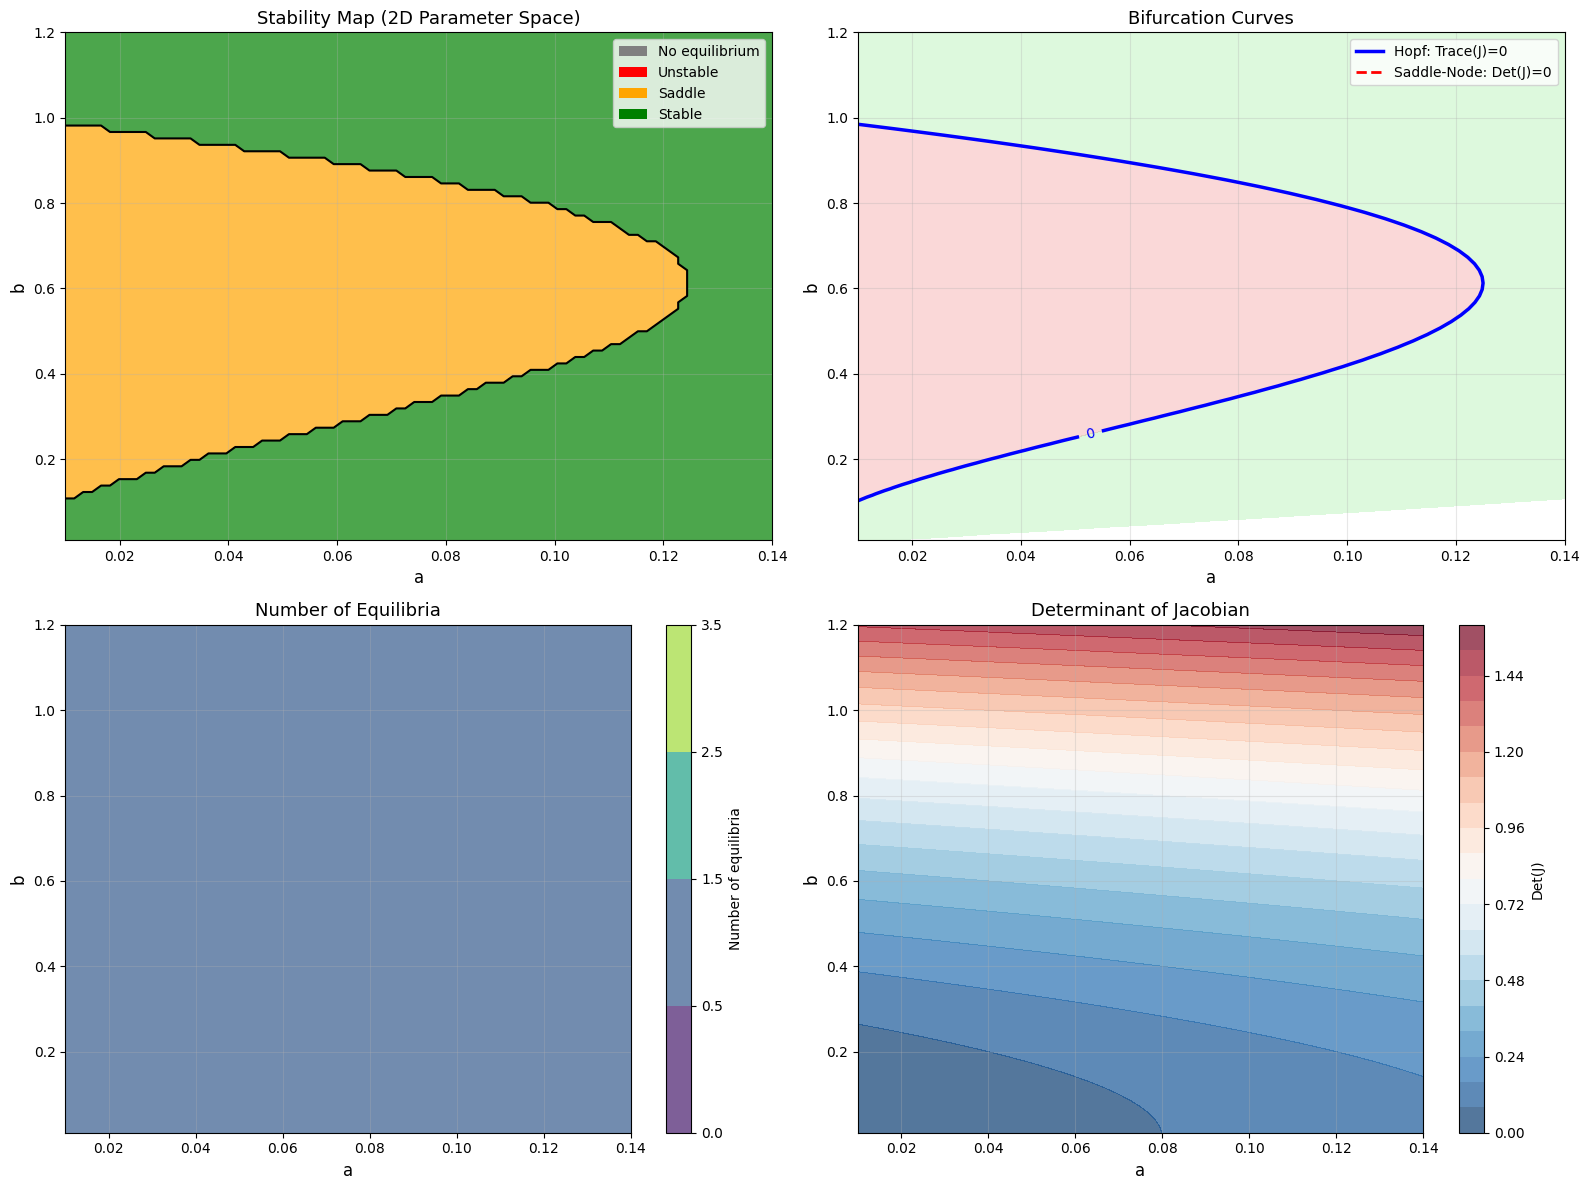


2D BIFURCATION ANALYSIS (a ∈ [0, 0.14], b ∈ [0, 1.2])

1. STABILITY REGIONS:
   🟩 GREEN: Stable equilibrium (attractor)
      - System converges to fixed point
      - Both eigenvalues have negative real parts
   🟧 ORANGE: Saddle point
      - Unstable in one direction, stable in another
      - Eigenvalues have opposite signs
   🟥 RED: Unstable equilibrium
      - System diverges from fixed point
      - At least one eigenvalue has positive real part
   ⬜ GRAY: No equilibrium in valid range

2. BIFURCATION CURVES:
   🔵 BLUE LINE (Trace = 0):
      - Hopf bifurcation boundary
      - Stability changes from stable to unstable or vice versa
      - May give rise to limit cycles
      - Occurs when eigenvalues cross imaginary axis

   🔴 RED DASHED LINE (Det = 0):
      - Saddle-node bifurcation boundary
      - Equilibria appear or disappear
      - One eigenvalue passes through zero

3. KEY OBSERVATIONS:
   - For LOW b values: No stable equilibrium exists
   - For HIGH b values: Stable 

In [15]:
# write your code for question 5 here. You can use more code cells as needed.

# Create 2D parameter space
a_values = np.linspace(0.01, 0.14, 80)
b_values = np.linspace(0.01, 1.2, 80)

# Create meshgrid
A_grid, B_grid = np.meshgrid(a_values, b_values)

# Storage for stability analysis
stability_map = np.zeros_like(A_grid)
num_equilibria_map = np.zeros_like(A_grid)
trace_map = np.zeros_like(A_grid)
det_map = np.zeros_like(A_grid)

# Analyze each parameter combination
print("Computing 2D bifurcation diagram... This may take a moment...")
for i in range(len(b_values)):
    if i % 10 == 0:
        print(f"Progress: {i}/{len(b_values)}")
    
    for j in range(len(a_values)):
        a = a_values[j]
        b = b_values[i]
        
        # Find equilibria for this (a, b) pair
        guesses = [[0.5, 5.0], [1.0, 1.0], [2.0, 0.5], [0.1, 3.0], [1.5, 2.0]]
        found_equilibria = []
        
        for guess in guesses:
            try:
                sol = fsolve(equilibrium_equations, guess, args=(a, b))
                residual = equilibrium_equations(sol, a, b)
                
                if np.sqrt(residual[0]**2 + residual[1]**2) < 1e-6 and sol[0] >= 0 and sol[1] >= 0:
                    # Check if not duplicate
                    is_new = True
                    for eq in found_equilibria:
                        if np.sqrt((sol[0]-eq[0])**2 + (sol[1]-eq[1])**2) < 1e-4:
                            is_new = False
                            break
                    
                    if is_new:
                        found_equilibria.append(sol)
            except:
                pass
        
        num_equilibria_map[i, j] = len(found_equilibria)
        
        # Analyze stability of primary equilibrium (if exists)
        if len(found_equilibria) > 0:
            # Take equilibrium closest to (1, 1) as primary
            primary_eq = min(found_equilibria, key=lambda eq: (eq[0]-1)**2 + (eq[1]-1)**2)
            
            # Calculate Jacobian and eigenvalues
            J = jacobian(primary_eq[0], primary_eq[1], a, b)
            eigenvalues = np.linalg.eigvals(J)
            trace = np.trace(J)
            det = np.linalg.det(J)
            
            trace_map[i, j] = trace
            det_map[i, j] = det
            
            # Classify stability
            # 1 = stable, 0 = unstable, -1 = saddle, -2 = no equilibrium
            real_part = np.real(eigenvalues[0])
            
            if det < 0:
                stability_map[i, j] = -1  # Saddle
            elif trace < 0:
                stability_map[i, j] = 1   # Stable
            else:
                stability_map[i, j] = 0   # Unstable
        else:
            stability_map[i, j] = -2  # No equilibrium

print("Computation complete!\n")

# Create comprehensive visualization
plt.close("bifurcation_2D_q5")
fig = plt.figure(num="bifurcation_2D_q5", figsize=(16, 12))

# Plot 1: Stability map
ax1 = plt.subplot(2, 2, 1)
colors_custom = ['gray', 'red', 'orange', 'green']
from matplotlib.colors import ListedColormap
cmap_custom = ListedColormap(colors_custom)
im1 = ax1.contourf(A_grid, B_grid, stability_map, levels=[-2.5, -1.5, -0.5, 0.5, 1.5], 
                   colors=['gray', 'red', 'orange', 'green'], alpha=0.7)
ax1.contour(A_grid, B_grid, stability_map, levels=[-1.5, -0.5, 0.5], colors='black', linewidths=1.5)
ax1.set_xlabel('a', fontsize=12)
ax1.set_ylabel('b', fontsize=12)
ax1.set_title('Stability Map (2D Parameter Space)', fontsize=13)
# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='gray', label='No equilibrium'),
                   Patch(facecolor='red', label='Unstable'),
                   Patch(facecolor='orange', label='Saddle'),
                   Patch(facecolor='green', label='Stable')]
ax1.legend(handles=legend_elements, loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot 2: Hopf bifurcation curve (Trace = 0, Det > 0)
ax2 = plt.subplot(2, 2, 2)
hopf_contour = ax2.contour(A_grid, B_grid, trace_map, levels=[0], colors='blue', linewidths=2.5)
ax2.clabel(hopf_contour, inline=True, fontsize=10)
ax2.contour(A_grid, B_grid, det_map, levels=[0], colors='red', linewidths=2, linestyles='--')
ax2.contourf(A_grid, B_grid, trace_map, levels=[-1, 0, 1], colors=['lightgreen', 'lightcoral'], alpha=0.3)
ax2.set_xlabel('a', fontsize=12)
ax2.set_ylabel('b', fontsize=12)
ax2.set_title('Bifurcation Curves', fontsize=13)
ax2.plot([], [], 'b-', linewidth=2.5, label='Hopf: Trace(J)=0')
ax2.plot([], [], 'r--', linewidth=2, label='Saddle-Node: Det(J)=0')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Number of equilibria
ax3 = plt.subplot(2, 2, 3)
im3 = ax3.contourf(A_grid, B_grid, num_equilibria_map, levels=[0, 0.5, 1.5, 2.5, 3.5], 
                   cmap='viridis', alpha=0.7)
plt.colorbar(im3, ax=ax3, label='Number of equilibria')
ax3.set_xlabel('a', fontsize=12)
ax3.set_ylabel('b', fontsize=12)
ax3.set_title('Number of Equilibria', fontsize=13)
ax3.grid(True, alpha=0.3)

# Plot 4: Determinant of Jacobian
ax4 = plt.subplot(2, 2, 4)
im4 = ax4.contourf(A_grid, B_grid, det_map, levels=20, cmap='RdBu_r', alpha=0.7)
ax4.contour(A_grid, B_grid, det_map, levels=[0], colors='black', linewidths=2)
plt.colorbar(im4, ax=ax4, label='Det(J)')
ax4.set_xlabel('a', fontsize=12)
ax4.set_ylabel('b', fontsize=12)
ax4.set_title('Determinant of Jacobian', fontsize=13)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis and explanation
print("\n" + "="*75)
print("2D BIFURCATION ANALYSIS (a ∈ [0, 0.14], b ∈ [0, 1.2])")
print("="*75)

print("\n1. STABILITY REGIONS:")
print("   🟩 GREEN: Stable equilibrium (attractor)")
print("      - System converges to fixed point")
print("      - Both eigenvalues have negative real parts")
print("   🟧 ORANGE: Saddle point")
print("      - Unstable in one direction, stable in another")
print("      - Eigenvalues have opposite signs")
print("   🟥 RED: Unstable equilibrium")
print("      - System diverges from fixed point")
print("      - At least one eigenvalue has positive real part")
print("   ⬜ GRAY: No equilibrium in valid range")

print("\n2. BIFURCATION CURVES:")
print("   🔵 BLUE LINE (Trace = 0):")
print("      - Hopf bifurcation boundary")
print("      - Stability changes from stable to unstable or vice versa")
print("      - May give rise to limit cycles")
print("      - Occurs when eigenvalues cross imaginary axis")
print("\n   🔴 RED DASHED LINE (Det = 0):")
print("      - Saddle-node bifurcation boundary")
print("      - Equilibria appear or disappear")
print("      - One eigenvalue passes through zero")

print("\n3. KEY OBSERVATIONS:")
print("   - For LOW b values: No stable equilibrium exists")
print("   - For HIGH b values: Stable equilibrium dominates")
print("   - The parameter 'a' affects the position of bifurcation curves")
print("   - Multiple bifurcations create different dynamical regimes")
print("   - Green region grows as b increases (stabilization)")

print("\n4. BIOLOGICAL INTERPRETATION (glucose degradation):")
print("   - Parameter 'a': feedback strength")
print("   - Parameter 'b': glucose input rate")
print("   - Low b: insufficient glucose → no steady state")
print("   - High b: excess glucose → stable steady state")
print("   - Transition region: complex dynamics possible")

print("="*75 + "\n")